In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
import PMDevice
import keyboard
import TLX_5

In [3]:
# Power meter connection

power_meter = PMDevice.PMDevice()
power_meter.find_devices()
power_meter.connect()

Number of found devices: 1

Resource name of device 0: USB0::0x1313::0x80B4::250214211::INSTR

Device connected
Last calibration date: 14-FEB-2025 



In [4]:
# Wavelength in nm
w = 1550
power_meter.set_wavelength(w)

In [4]:
power_meter.set_autorange(True)

In [25]:
units = "dBm"

power_meter.set_unit(units)

Units set to dBm


In [6]:
power_meter.newTimeOut(20)

In [26]:
power_meter.SetAvMeasure(1)

In [27]:
p = power_meter.read_power()
print(p)

-18.1493


In [28]:
measure = power_meter.measure_series(count=5, interval=1)

2026-08-17 15:40:21.747876 : -18.1498 dBm
2026-08-17 15:40:22.750078 : -18.1541 dBm
2026-08-17 15:40:23.753122 : -18.156 dBm
2026-08-17 15:40:24.756294 : -18.1513 dBm
2026-08-17 15:40:25.759050 : -18.1517 dBm


KeyboardInterrupt: 

In [9]:

while True:
    p = power_meter.read_power()
    print(f"Power={p} {units}")
    time.sleep(1.0)
    if keyboard.is_pressed("q"):
        break

Power=1.55327e-05 W
Power=1.55421e-05 W
Power=1.55394e-05 W
Power=1.55433e-05 W
Power=1.55404e-05 W
Power=1.55438e-05 W
Power=1.55375e-05 W
Power=1.55408e-05 W
Power=1.55386e-05 W
Power=1.55377e-05 W
Power=1.55381e-05 W
Power=1.55471e-05 W
Power=1.55538e-05 W
Power=1.55561e-05 W


KeyboardInterrupt: 

In [31]:
measure_length = np.linspace(0, 60, 61)

size=len(measure_length)


In [32]:


power_meter.newTimeOut(5)

power_meter.SetAvMeasureTime(2)

mes_power = []

time=[]
 


In [33]:
for i in range(size):
    time.append(datetime.now())
    pwr = power_meter.read_power()
    mes_power.append(pwr)

    
    

In [34]:
mean=np.mean(mes_power)
std=np.std(mes_power)
mes_power=[item for item in mes_power]
print(f"Mean Power={mean:.2f} Standard Deviation ={std:.2f}")



Mean Power=-18.15 Standard Deviation =0.00


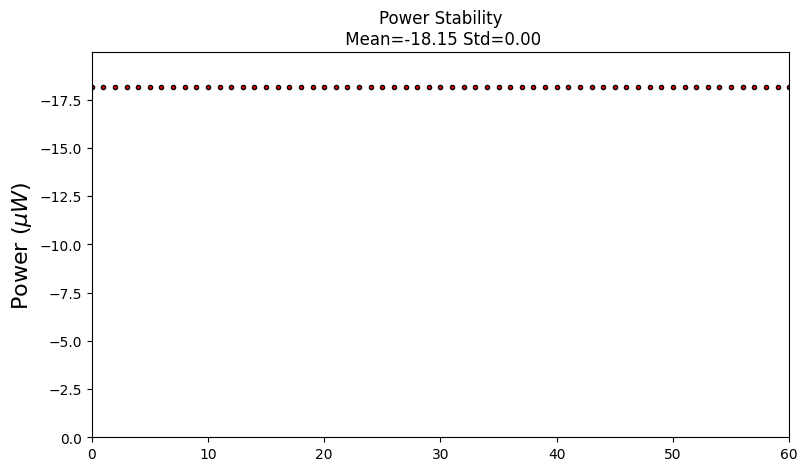

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    measure_length,mes_power,
    marker='o',         # square markers
    markersize=3,
    markerfacecolor='red',
    markeredgecolor='black',
    linestyle='None'    # disables line
)
    
ax.set_xlim(np.min(measure_length),np.max(measure_length))
ax.set_ylim(0,np.max(mes_power)+0.1*np.max(mes_power))
ax.set_ylabel(r'Power ($\mu W$)', fontsize=16)
plt.title(f"Power Stability\n Mean={mean:.2f} Std={std:.2f}")
plt.show()

In [ ]:
power_meter.disconnect()